In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch import nn
from torchmetrics.classification import MulticlassAccuracy
from sklearn.preprocessing import StandardScaler
from torchmetrics.classification import MulticlassConfusionMatrix
from torchmetrics.utilities.plot import plot_confusion_matrix
from pathlib import Path

In [2]:
df = pd.read_csv("Dry_Bean_Dataset.csv")

In [3]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [5]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [6]:
df["Class"].unique()

<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str

In [7]:
df["Class"].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

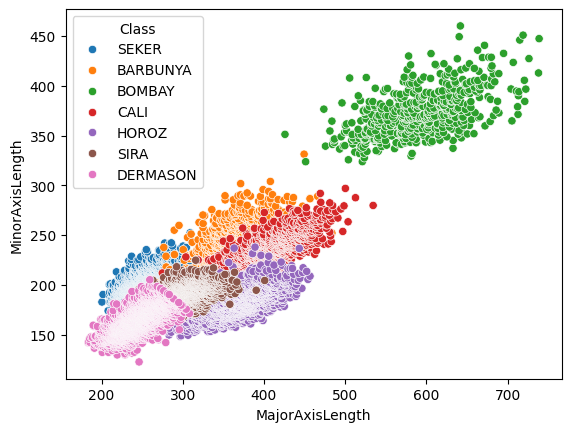

In [8]:
sns.scatterplot(x=df['MajorAxisLength'], y=df['MinorAxisLength'], hue=df['Class'])
plt.show()

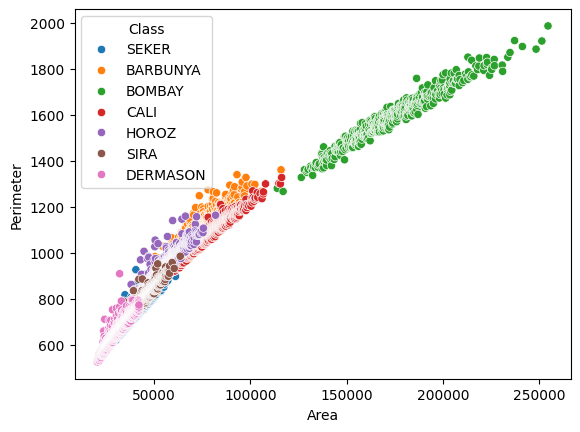

In [9]:
sns.scatterplot(x=df['Area'], y=df['Perimeter'], hue=df['Class'])
plt.show()

In [10]:
X = df[["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter",
       "Extent", "Solidity", "roundness", "Compactness", "ShapeFactor1", "ShapeFactor2", "ShapeFactor3", "ShapeFactor4"]].values
y = df["Class"].values

In [11]:
y

<StringArray>
[   'SEKER',    'SEKER',    'SEKER',    'SEKER',    'SEKER',    'SEKER',
    'SEKER',    'SEKER',    'SEKER',    'SEKER',
 ...
 'DERMASON', 'DERMASON', 'DERMASON', 'DERMASON', 'DERMASON', 'DERMASON',
 'DERMASON', 'DERMASON', 'DERMASON', 'DERMASON']
Length: 13611, dtype: str

In [12]:
le = LabelEncoder()
y = le.fit_transform(y)
y

array([5, 5, 5, ..., 3, 3, 3], shape=(13611,))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
y_test

array([3, 1, 6, ..., 4, 2, 3], shape=(2723,))

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([10888, 16]),
 torch.Size([2723, 16]),
 torch.Size([10888]),
 torch.Size([2723]))

In [17]:
class BeanClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(16,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,7)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [18]:
accuracy = MulticlassAccuracy(num_classes=7)

In [19]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

epochs = 300
model = BeanClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.argmax(logits, dim=1)
    acc = accuracy(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    ### TEST ###
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.9522 | Acc: 14.29% | Test Loss: 1.9492 | Test Acc: 14.29%
Epoch 20 | Loss: 1.8320 | Acc: 26.60% | Test Loss: 1.8151 | Test Acc: 34.31%
Epoch 40 | Loss: 1.1683 | Acc: 54.06% | Test Loss: 1.1383 | Test Acc: 57.05%
Epoch 60 | Loss: 0.5291 | Acc: 78.33% | Test Loss: 0.5094 | Test Acc: 78.80%
Epoch 80 | Loss: 0.3776 | Acc: 86.54% | Test Loss: 0.3663 | Test Acc: 86.95%
Epoch 100 | Loss: 0.2847 | Acc: 90.60% | Test Loss: 0.2896 | Test Acc: 90.60%
Epoch 120 | Loss: 0.2310 | Acc: 92.72% | Test Loss: 0.2440 | Test Acc: 92.63%
Epoch 140 | Loss: 0.2069 | Acc: 93.52% | Test Loss: 0.2253 | Test Acc: 93.02%
Epoch 160 | Loss: 0.1957 | Acc: 93.91% | Test Loss: 0.2177 | Test Acc: 93.01%
Epoch 180 | Loss: 0.1898 | Acc: 94.09% | Test Loss: 0.2146 | Test Acc: 93.29%
Epoch 200 | Loss: 0.1856 | Acc: 94.24% | Test Loss: 0.2121 | Test Acc: 93.16%
Epoch 220 | Loss: 0.1843 | Acc: 94.15% | Test Loss: 0.2121 | Test Acc: 93.22%
Epoch 240 | Loss: 0.1798 | Acc: 94.33% | Test Loss: 0.2092 | Test Acc:

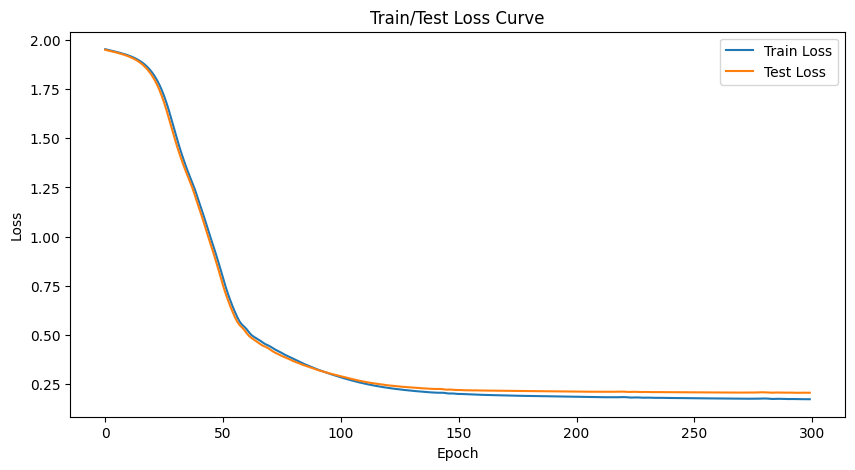

In [20]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()
plt.show()

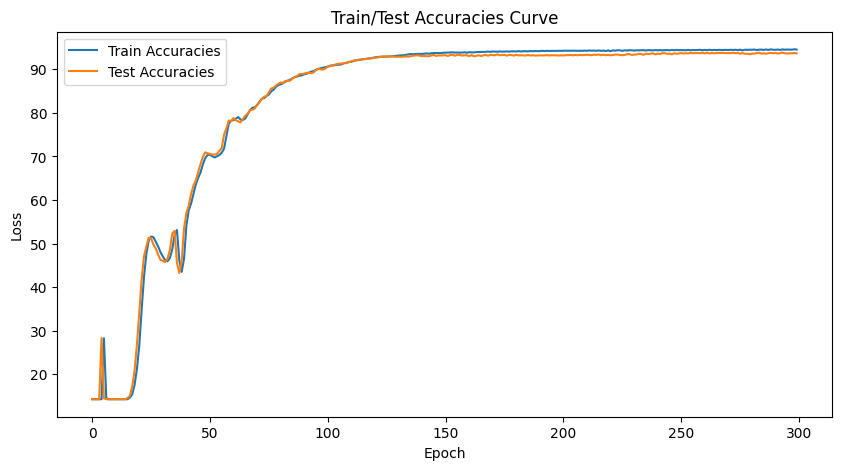

In [21]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Accuracies")
plt.plot(test_accuracies, label="Test Accuracies")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Accuracies Curve")
plt.legend()
plt.show()

In [22]:
cm = MulticlassConfusionMatrix(num_classes=7)
matrix = cm(test_pred, y_test)

In [23]:
print(matrix)

tensor([[241,   0,  15,   0,   0,   4,   5],
        [  0, 103,   1,   0,   0,   0,   0],
        [ 12,   0, 306,   0,   5,   2,   1],
        [  0,   0,   0, 655,   0,  11,  43],
        [  2,   0,   3,   5, 369,   0,   7],
        [  2,   0,   0,   5,   0, 390,   9],
        [  4,   0,   0,  46,   8,   7, 462]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

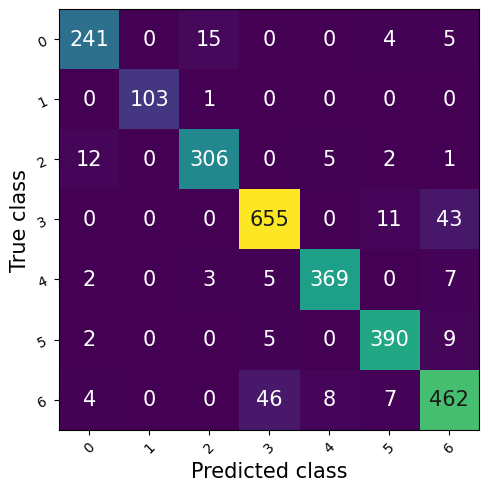

In [24]:
plot_confusion_matrix(matrix)

In [25]:
# test

In [31]:
index = 6200
new_sample = df.iloc[index, :-1].values.reshape(1, -1)

actual_label = df.iloc[index]['Class']

new_sample_scaled = scaler.transform(new_sample)

new_sample_tensor = torch.tensor(new_sample_scaled, dtype=torch.float32)

model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    predicted_class = torch.argmax(logits, dim=1).item()

predicted_label = le.inverse_transform([predicted_class])[0]

print(f"Satır İndeksi: {index}")
print(f"Gerçek Tür: {actual_label}")
print(f"Modelin Tahmini: {predicted_label}")

Satır İndeksi: 6200
Gerçek Tür: HOROZ
Modelin Tahmini: HOROZ


In [32]:
#model save

In [33]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "bean_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [34]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'BARBUNYA': np.int64(0), 'BOMBAY': np.int64(1), 'CALI': np.int64(2), 'DERMASON': np.int64(3), 'HOROZ': np.int64(4), 'SEKER': np.int64(5), 'SIRA': np.int64(6)}


In [35]:
import json
from pathlib import Path

# scaler: fit edilmiş StandardScaler
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# 1) Scaler bilgisi
scaler_data = {
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist()
}
with open(models_dir / "scaler.json", "w", encoding="utf-8") as f:
    json.dump(scaler_data, f, ensure_ascii=False, indent=2)

# 2) Sınıf sırası
class_names = le.classes_.tolist()
with open(models_dir / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("models/scaler.json ve models/class_names.json kaydedildi.")

models/scaler.json ve models/class_names.json kaydedildi.
